In [1]:
import numpy as np
from numba import njit, prange

@njit(parallel=True)  
def sample_lba(n_samples, A, b, v, s, t0):
    """
    Samples from the Linear Ballistic Accumulator (LBA).
    Robust against 'inf' errors and negative choice indices.
    """
    
    n_choices = len(v)
    rts = np.empty(n_samples, dtype=np.float64)
    choices = np.empty(n_samples, dtype=np.int32)
    
    threshold = A + b

    for i in prange(n_samples):
        
        # Loop until a valid race is generated (at least one positive drift)
        while True:
            min_t = 1e308      # Initialize with a huge number (simulating infinity)
            winner = -1        # Initialize with an invalid choice index
            
            for c in range(n_choices):
                # 1. Sample Start Point
                start_point = np.random.random() * A
                
                # 2. Sample Drift Rate
                drift_rate = np.random.normal(v[c], s)
                
                # 3. Calculate Time
                if drift_rate > 0:
                    # Only calculate time if moving towards threshold
                    t_accum = (threshold - start_point) / drift_rate
                    
                    if t_accum < min_t:
                        min_t = t_accum
                        winner = c
            
            # 4. Valid Trial Check
            # We only record and break if we found a winner (winner != -1)
            if winner != -1:
                rts[i] = t0 + min_t
                choices[i] = winner
                break 

    return rts, choices

In [25]:
import numpy as np

# --- Parameters ---
N_TRIALS = 10000
A_START = 1.0       # Max start point
B_GAP = 0.5         # Gap (so Absolute Threshold = 1.0 + 0.5 = 1.0)
T0 = 0.2
V_RATES = np.array([2.5, 1.5, 1.5]) # 3 Choices
S_RATE = 1.0        # Shared drift noise

# --- Simulation ---
rts, choices = sample_lba(N_TRIALS, A_START, B_GAP, V_RATES, S_RATE, T0)

# --- Check Results ---
print(f"Mean RT: {np.mean(rts):.3f}")
print(f"Choice Probabilities: {np.bincount(choices) / N_TRIALS}")

Mean RT: 0.560
Choice Probabilities: [0.5772 0.212  0.2108]


<Axes: ylabel='Count'>

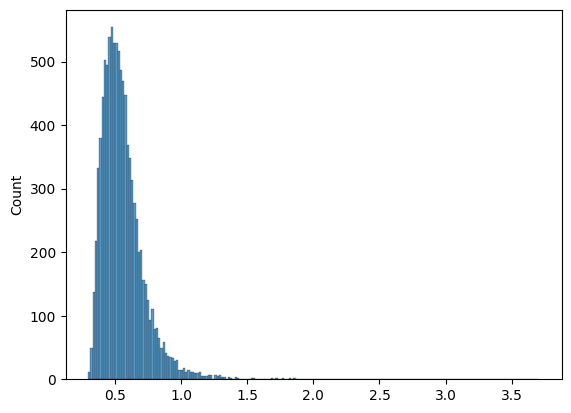

In [26]:
import seaborn as sns
sns.histplot(rts)

In [33]:
import numpy as np
from numba import njit, prange


@njit
def sample_lba_trial(
    v: np.ndarray,
    A: float,
    b: float,
    tau: float,
    s: float = 1.0,
    max_time: int = 10,
) -> np.ndarray:

    n_choices = v.shape[0]
    threshold = A + b
    rt = -1
    choice = -1

    while True:
        min_t = 1e25
        winner = -1
        for c in range(n_choices):
            # 1. Sample Start Point
            start_point = np.random.random() * A
            # 2. Sample Drift Rate
            drift_rate = np.random.normal(v[c], s)
            # 3. Calculate Time
            if drift_rate > 0:
                t_accum = (threshold - start_point) / drift_rate
                if t_accum < min_t:
                    min_t = t_accum
                    winner = c
            # We only record and break if we found a winner (winner != -1)
        if winner != -1:
            break 
    if min_t < max_time:
        return np.array([min_t+tau, winner], dtype=np.float32)
    else:
        return np.array([-1.0, -1.0], dtype=np.float32)

@njit(parallel=True)
def simulate_lba(
    v: np.ndarray,
    A: np.ndarray,
    tau: np.ndarray,
    b: np.ndarray,
    sigma: float = 1.0,
    max_time: int = 10
):
    n = v.shape[0]
    sim_data = np.zeros((n, 2), dtype=np.float32)

    for i in prange(n):
        sim_trial = sample_lba_trial(
            v=v[i],
            A=A[i],
            tau=tau[i],
            b=b[i],
            s=sigma,
            max_time=max_time
        )
        sim_data[i] = sim_trial

    return sim_data

In [108]:
simulate_lba(v=np.array(([4,2,3],[0,2,3])), A=np.array(([2,2])),
             tau=np.array(([0.5,0.5])), b=np.array(([0.5,0.5])), sigma=1,max_time=10)

array([[0.71450794, 0.        ],
       [0.99070054, 2.        ]], dtype=float32)

In [143]:
import numpy as np
from numba import njit, prange

def as_1d(x, n: int, allow_scalar: bool = True) -> np.ndarray:
    """Return a 1D array of length n. Broadcast scalars if allowed; else validate."""
    a = np.asarray(x)
    if a.ndim == 0:
        if allow_scalar:
            return np.full((n,), a.item())
    a = a.reshape(-1)
    if a.size == 1 and allow_scalar:
        return np.full((n,), a.item())
    if a.size != n:
        raise ValueError(f"array has length {a.size}; expected {n}.")
    return a
@njit
def sample_lba_trial(
    v: np.ndarray,
    A: float,
    b: float,
    tau: float,
    s: float = 1.0,
    max_time: int = 10,
) -> np.ndarray:

    n_choices = v.shape[0]
    threshold = A + b
    rt = -1
    choice = -1

    while True:
        min_t = 1e25
        winner = -1
        for c in range(n_choices):
            # 1. Sample Start Point
            start_point = np.random.random() * A
            # 2. Sample Drift Rate
            drift_rate = np.random.normal(v[c], s)
            # 3. Calculate Time
            if drift_rate > 0:
                t_accum = (threshold - start_point) / drift_rate
                if t_accum < min_t:
                    min_t = t_accum
                    winner = c
            # We only record and break if we found a winner (winner != -1)
        if winner != -1:
            break 
    if min_t < max_time:
        return np.array([min_t+tau, winner], dtype=np.float32)
    else:
        return np.array([-1.0, -1.0], dtype=np.float32)

@njit(parallel=True)
def simulate_lba(
    v: np.ndarray,
    A: np.ndarray,
    tau: np.ndarray,
    b: np.ndarray,
    sigma: float = 1.0,
    max_time: int = 10
):
    n = v.shape[0]
    sim_data = np.zeros((n, 2), dtype=np.float32)

    for i in prange(n):
        sim_trial = sample_lba_trial(
            v=v[i],
            A=A[i],
            tau=tau[i],
            b=b[i],
            s=sigma,
            max_time=max_time
        )
        sim_data[i] = sim_trial

    return sim_data


def sample_lba_prior():
    return {
        "v":        {"intercept": np.random.gamma(2.5, 0.5),
                     "slope": 0.0},
        "v_diff":    {"intercept": np.random.lognormal(0, 0.5),
                     "slope":  0.0},
        "tau":      {"intercept": np.random.gamma(2.0, 0.2),
                     "slope": 0.0},
        "b":      {"intercept": np.random.gamma(0.5, 0.2),
                     "slope": 0.0},
        "A":    {"intercept": np.random.gamma(1.0, 0.4),
                     "slope": 0.0}
    }

class LBA():

    def __init__(self, max_time: int = 10):
        self.max_time = max_time

    def prepare_params(
        self,
        params: dict[str, np.ndarray],
        num_obs: int,
        context: dict[str, np.ndarray] | None = None,
    ) -> dict[str, np.ndarray]:
        """
        Build per-trial K-way drift from scalars; no dtype control here.
        Expects in `params`: v, optional v_diff, b, tau, A (len == num_obs or scalars).
        Expects in `context`: 'correct_idx' (len == num_obs), optional 'num_alternatives'.
        """
        context = context or {}

        if "correct_idx" not in context:
            raise ValueError("LBA requires context['correct_idx'].")
        correct_idx = np.asarray(context["correct_idx"]).reshape(-1)
        if correct_idx.shape[0] != num_obs:
            raise ValueError(f"correct_idx length {correct_idx.shape[0]} != num_obs {num_obs}")

        num_alternatives = int(context.get("num_alternatives", int(correct_idx.max()) + 1))
        if num_alternatives < 1:
            raise ValueError("num_alternatives must be >= 1.")

        v_base = as_1d(params["v"]["intercept"], num_obs)
        v_diff = as_1d(params["v_diff"]["intercept"], num_obs)
        A      = as_1d(params["A"]["intercept"], num_obs)
        tau    = as_1d(params["tau"]["intercept"], num_obs)
        b  = as_1d(params["b"]["intercept"], num_obs)


        # Build per-trial K-vector drift
        v_correct   = v_base + 0.5 * v_diff
        v_incorrect = v_base - 0.5 * v_diff
        v = np.full((num_obs, num_alternatives), 0.0)
        for i in range(num_obs):
            v[i, :] = v_incorrect[i]
            v[i, correct_idx[i]] = v_correct[i]

        return {"v": v, "A": A, "tau": tau, "b": b}

    @staticmethod
    def build_context(num_obs: int, num_alternatives: int) -> dict[str, np.ndarray]:
        correct_idx = np.random.randint(0, num_alternatives, size=num_obs)
        return {"correct_idx": correct_idx, "num_alternatives": num_alternatives}

    @staticmethod
    def build_default_context(num_obs: int) -> dict[str, np.ndarray]:
        num_alternatives = np.random.randint(2, 5)  # Randomly pick 2-4 alternatives per batch
        return LBA.build_context(num_obs, num_alternatives)

    def simulate(self, params: dict[str, np.ndarray], context=None):
        results = simulate_lba(**params, max_time=self.max_time)
        rts = results[:, 0][..., None]
        choices = results[:, 1][..., None]
        return {"rts": rts, "choices": choices}
    
    def sample(self, batch_size: int | tuple, num_obs: int = 500, num_alternatives: int = 3, context=None):

        if isinstance(batch_size, tuple):
            batch_size = batch_size[0]
            
        if context == None:
            context = self.build_context(num_obs, num_alternatives)

        parameters = []
        rts = []
        choices = []

        for i in range(batch_size):
            prior_draw = sample_lba_prior()
            prepared_params = self.prepare_params(params=prior_draw, num_obs=num_obs, context=context)
            results = self.simulate(params=prepared_params, context=context)
            rts.append(results["rts"])
            choices.append(results["choices"])
            parameters.append(prior_draw)

        prior_draws = {}

        for cycle_dict in parameters:
            for key, subdict in cycle_dict.items():
                if key not in prior_draws:
                    prior_draws[key] = {}
                for subkey, value in subdict.items():
                    prior_draws[key].setdefault(subkey, []).append(value)

        
        sim_data = {"rts": np.array(rts), "choices": np.array(choices)}
        return prior_draws | sim_data



In [157]:
x = LBA()
sample= x.sample(batch_size=3)

In [158]:
sample

{'v': {'intercept': [0.8590356155579364, 1.08946686431424, 0.8806795034500718],
  'slope': [0.0, 0.0, 0.0]},
 'v_diff': {'intercept': [0.7798400966429622,
   0.6121217809840129,
   0.7701983392146245],
  'slope': [0.0, 0.0, 0.0]},
 'tau': {'intercept': [0.28028500173968196,
   0.8075134725211708,
   0.05273577265872799],
  'slope': [0.0, 0.0, 0.0]},
 'b': {'intercept': [0.02854221803639181,
   0.07710817688142628,
   0.012918786317719212],
  'slope': [0.0, 0.0, 0.0]},
 'A': {'intercept': [0.05102356509350684,
   0.16387317723875305,
   0.03596211261073861],
  'slope': [0.0, 0.0, 0.0]},
 'rts': array([[[0.3033622 ],
         [0.35443148],
         [0.31181905],
         ...,
         [0.30964583],
         [0.30105716],
         [0.2984067 ]],
 
        [[0.8562356 ],
         [0.9100892 ],
         [0.8726143 ],
         ...,
         [0.9446487 ],
         [0.9876773 ],
         [0.89661515]],
 
        [[0.07058873],
         [0.05926587],
         [0.07706798],
         ...,
       